In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [3]:
df = pd.read_csv(r"C:\Users\Aathira\Desktop\Validation_cross\Chocolate Sales.csv")


print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (3282, 6)
     Sales Person    Country              Product        Date      Amount  \
0  Jehu Rudeforth         UK      Mint Chip Choco  04/01/2022   $5,320.00   
1     Van Tuxwell      India        85% Dark Bars  01/08/2022   $7,896.00   
2    Gigi Bohling      India  Peanut Butter Cubes  07/07/2022   $4,501.00   
3    Jan Morforth  Australia  Peanut Butter Cubes  27/04/2022  $12,726.00   
4  Jehu Rudeforth         UK  Peanut Butter Cubes  24/02/2022  $13,685.00   

   Boxes Shipped  
0            180  
1             94  
2             91  
3            342  
4            184  


In [4]:
df = df.dropna()


In [5]:
label_encoders = {}

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

In [7]:
print(df.columns)


Index(['Sales Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes Shipped'],
      dtype='object')


In [8]:
target_column = 'Amount'

X = df.drop(columns=[target_column])
y = df[target_column]


In [9]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [10]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

rmse_scores = np.sqrt(-cv_scores)

In [11]:
for i, score in enumerate(rmse_scores, 1):
    print(f"Fold {i} RMSE: {score:.2f}")

print("\nAverage RMSE:", rmse_scores.mean())

Fold 1 RMSE: 583.62
Fold 2 RMSE: 574.72
Fold 3 RMSE: 551.11
Fold 4 RMSE: 573.46
Fold 5 RMSE: 575.32

Average RMSE: 571.6461869117497


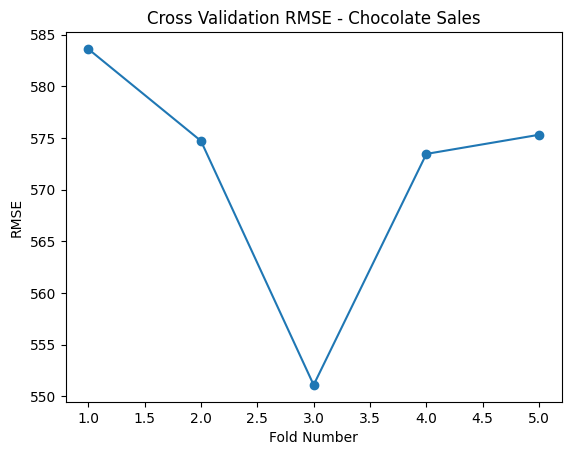

In [12]:
plt.figure()
plt.plot(range(1, 6), rmse_scores, marker='o')
plt.xlabel("Fold Number")
plt.ylabel("RMSE")
plt.title("Cross Validation RMSE - Chocolate Sales")
plt.show()